In [4]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

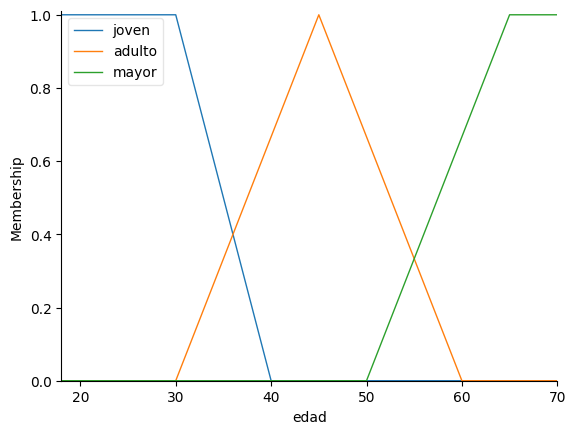

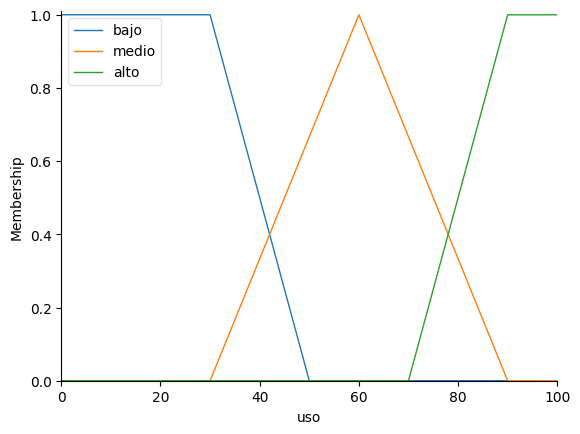

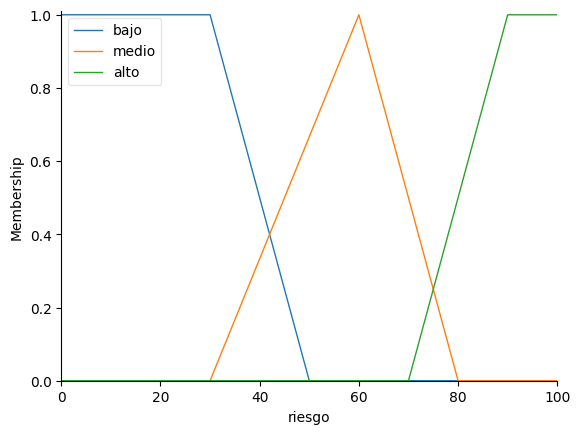

In [5]:
# -------------------------------------------------------------------
# Definición de Variables y Funciones de Pertenencia
# -------------------------------------------------------------------

# Universos de discurso (rangos de variables)
# Edad: 18-70 años
edad = ctrl.Antecedent(np.arange(18, 71, 1), 'edad')
# Uso: 0-100%
uso = ctrl.Antecedent(np.arange(0, 101, 1), 'uso')
# Riesgo: 0-100%
riesgo = ctrl.Consequent(np.arange(0, 101, 1), 'riesgo')

# Definición de las funciones de pertenencia (triangulares/trapezoidales)
# Se han elegido valores que cubren uniformemente los rangos.

# EDAD: JOVEN, ADULTO, MAYOR
edad['joven'] = fuzz.trapmf(edad.universe, [18, 18, 30, 40])
edad['adulto'] = fuzz.trimf(edad.universe, [30, 45, 60])
edad['mayor'] = fuzz.trapmf(edad.universe, [50, 65, 70, 70])

# USO: BAJO, MEDIO, ALTO
uso['bajo'] = fuzz.trapmf(uso.universe, [0, 0, 30, 50])
uso['medio'] = fuzz.trimf(uso.universe, [30, 60, 90])
uso['alto'] = fuzz.trapmf(uso.universe, [70, 90, 100, 100])

# RIESGO: BAJO, MEDIO, ALTO
riesgo['bajo'] = fuzz.trapmf(riesgo.universe, [0, 0, 30, 50])
riesgo['medio'] = fuzz.trimf(riesgo.universe, [30, 60, 80])
riesgo['alto'] = fuzz.trapmf(riesgo.universe, [70, 90, 100, 100])

# Guardar las gráficas de las funciones de pertenencia
edad.view(filename='funciones_pertenencia_edad.png')
uso.view(filename='funciones_pertenencia_uso.png')
riesgo.view(filename='funciones_pertenencia_riesgo.png')

In [8]:
# -------------------------------------------------------------------
# Aplicación de Reglas de Inferencia (Método Mandani)
# -------------------------------------------------------------------

# Uso/Edad | JOVEN  | ADULTO | MAYOR
# ---------|--------|--------|------
# BAJO     | MEDIO  | BAJO   | BAJO
# MEDIO    | ALTO   | MEDIO  | MEDIO
# ALTO     | ALTO   | ALTO   | ALTO

rule1 = ctrl.Rule(edad['joven'] & uso['bajo'], riesgo['medio'])
rule2 = ctrl.Rule(edad['joven'] & uso['medio'], riesgo['alto'])
rule3 = ctrl.Rule(edad['joven'] & uso['alto'], riesgo['alto'])

rule4 = ctrl.Rule(edad['adulto'] & uso['bajo'], riesgo['bajo'])
rule5 = ctrl.Rule(edad['adulto'] & uso['medio'], riesgo['medio'])
rule6 = ctrl.Rule(edad['adulto'] & uso['alto'], riesgo['alto'])

rule7 = ctrl.Rule(edad['mayor'] & uso['bajo'], riesgo['bajo'])
rule8 = ctrl.Rule(edad['mayor'] & uso['medio'], riesgo['medio'])
rule9 = ctrl.Rule(edad['mayor'] & uso['alto'], riesgo['alto'])

# Creación del Sistema de Control
riesgo_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9])
riesgo_simulador = ctrl.ControlSystemSimulation(riesgo_ctrl)

In [9]:
# -------------------------------------------------------------------
# Fuzzyficación de Entradas (Caso: Edad=25, Uso=50)
# -------------------------------------------------------------------

riesgo_simulador.input['edad'] = 25
riesgo_simulador.input['uso'] = 50

Edad de entrada: 25 años
Uso de vehículo de entrada: 50%
-----------------------------------
Porcentaje de Riesgo Financiero (Centroide): 88.02%


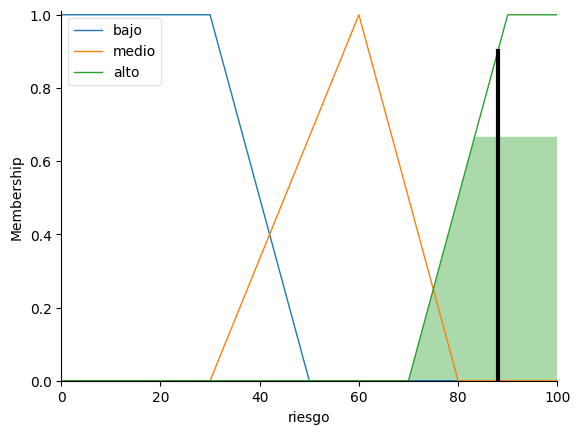

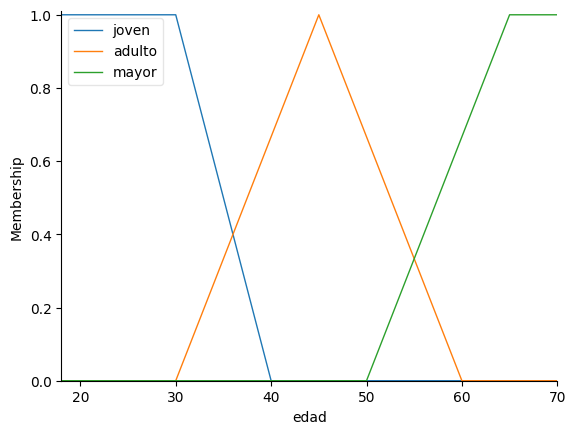

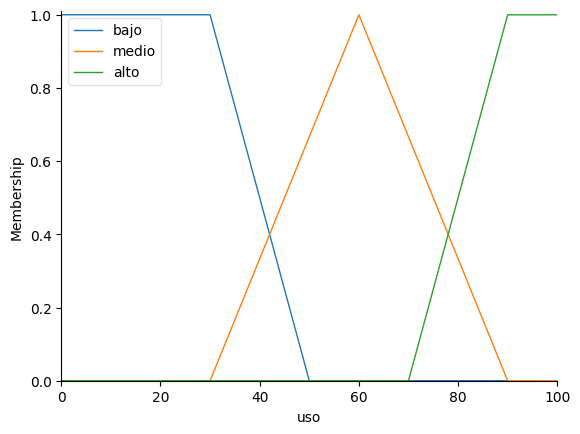

In [17]:
# -------------------------------------------------------------------
# Agregación y Defuzzificación (Centroide)
# -------------------------------------------------------------------

# Computar el resultado (Ejecuta la fuzzyficación, aplicación/agregación y defuzzificación)
riesgo_simulador.compute()

# Obtener el resultado final
riesgo_final = riesgo_simulador.output['riesgo']

# Imprimir los resultados
print(f"Edad de entrada: 25 años")
print(f"Uso de vehículo de entrada: 50%")
print(f"-----------------------------------")
print(f"Porcentaje de Riesgo Financiero (Centroide): {riesgo_final:.2f}%")

riesgo.view(sim=riesgo_simulador)
edad.view()
uso.view()